In [355]:
import pandas as pd
import re 

In [356]:

# # Loads every sheet into a dict: {"Sheet1": df1, "Sheet2": df2, ...}
# all_sheets = pd.read_excel("DV.xlsx", sheet_name=None)
# for name, df in all_sheets.items():
#     df.to_csv(f"{name}.csv", index=False)

In [357]:
# import numpy as np
# import re

# df_eg = pd.read_csv("Energy, GHG.csv", header=None)

# print(f"Kích thước dữ liệu gốc: {df_eg.shape}")
# display(df_eg.head())

# 1. Load the dataset

In [358]:
df1 = pd.read_csv('Energy_Consumption.csv')
df1.head()

,Energy Consumption,unit,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,...,Nov,Dec,YTD,Q1,Q2,Q3,Q4,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,Coal/ Than 5A (DV),Ton,1233.522,983.00,2414.661,2198.795,2197.301,2170.990,2442.916,2148.882,...,1649.300,2061.215,NaN,4631.183,6567.086,6310.711,5464.470,NaN,NaN,NaN
1,Coal/ Than 4A.1 (DV),Ton,443.000,251.25,543.069,88.335,774.190,319.418,508.880,630.609,...,113.760,369.092,NaN,1237.319,1181.943,1584.048,501.752,NaN,NaN,NaN
2,Coal/ Than import coal (DV) (than nhập khẩu),Ton,0.000,92.48,430.117,722.734,0.000,434.630,375.270,77.210,...,352.255,533.023,NaN,522.597,1157.364,452.480,1436.158,NaN,NaN,NaN
3,Than cám qua sàng / Than 5A under screen DV,Ton,114.000,88.00,206.339,209.205,204.699,201.010,188.848,204.034,...,156.700,175.785,NaN,408.339,614.914,526.657,485.530,NaN,NaN,NaN
4,Coal/ Than 5A (YB),Ton,0.000,0.00,0.000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000,0.000,0.000,0.000,NaN,NaN,NaN


In [359]:
df1.tail()

,Energy Consumption,unit,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,...,Nov,Dec,YTD,Q1,Q2,Q3,Q4,Unnamed: 19,Unnamed: 20,Unnamed: 21
60,"Specific Energy Consumption-Coal, Biomass",GJ/ton,5.926664,7.137908,6.329776,6.385239,6.279040,6.203684,6.25075,6.459163,...,6.057863,6.170735,6.332632,6.366192,6.288172,6.415744,6.262292,NaN,NaN,NaN
61,Specific Energy Consumption-Coal Gas (DV),GJ/ton,4.540558,3.879307,4.790834,4.879152,4.660522,4.644775,4.64025,4.692017,...,4.812441,4.570350,4.687494,4.548450,4.726677,4.759708,4.672862,NaN,NaN,NaN
62,Specific Energy Consumption-Coal Gas (YB),GJ/ton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.090000,0.090000,NaN,NaN,NaN,0.090000,NaN,NaN,NaN
63,Specific Energy Consumption-Coal Gas,GJ/ton,4.540558,3.879307,4.790834,4.879152,4.660522,4.644775,4.64025,4.692017,...,4.812441,4.451743,4.676003,4.548450,4.726677,4.759708,4.625266,NaN,NaN,NaN
64,NaN,NaN,17330.000000,17932.000000,31613.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [360]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Energy Consumption  64 non-null     object 
 1   unit                64 non-null     object 
 2    Jan                54 non-null     float64
 3    Feb                54 non-null     float64
 4    Mar                54 non-null     float64
 5    Apr                49 non-null     float64
 6    May                49 non-null     float64
 7    Jun                49 non-null     float64
 8    Jul                49 non-null     float64
 9    Aug                48 non-null     float64
 10   Sep                49 non-null     float64
 11   Oct                49 non-null     float64
 12   Nov                49 non-null     float64
 13   Dec                52 non-null     float64
 14   YTD                55 non-null     float64
 15  Q1                  62 non-null     float64
 16   Q2       

In [361]:
# # Tìm index của các dòng chứa chữ 'unit'
# header_rows = df_eg[df_eg[1].astype(str).str.strip().str.lower() == 'unit'].index.tolist()
# print("Vị trí các dòng Header được tìm thấy:", header_rows)

# # Cắt DataFrame lớn thành dictionary chứa các DataFrame nhỏ
# tables = {}
# for i in range(len(header_rows)):
#     start_idx = header_rows[i]

#     # Lấy tên bảng từ cột đầu tiên
#     table_name = str(df_eg.iloc[start_idx, 0]).strip()

#     # Xác định điểm kết thúc của bảng này
#     end_idx = header_rows[i+1] if i + 1 < len(header_rows) else len(df_eg)

#     # Cắt lấy dữ liệu và drop các dòng trống hoàn toàn
#     df_sub = df_eg.iloc[start_idx:end_idx].dropna(how='all').reset_index(drop=True)
#     tables[table_name] = df_sub

# print(f"Đã tách thành công {len(tables)} bảng: {list(tables.keys())}")

# 2. Data Cleaning and Preprocessing

In [362]:
print("Số lượng giá trị thiếu trên từng cột:")
print(df1.isnull().sum())

print("Kiểu dữ liệu của từng cột:")
print(df1.dtypes)

print("Thống kê mô tả nhanh cho dữ liệu số:")
display(df1.describe())

Số lượng giá trị thiếu trên từng cột:
Energy Consumption     1
unit                   1
 Jan                  11
 Feb                  11
 Mar                  11
 Apr                  16
 May                  16
 Jun                  16
 Jul                  16
 Aug                  17
 Sep                  16
 Oct                  16
 Nov                  16
 Dec                  13
 YTD                  10
Q1                     3
 Q2                    3
Q3                     3
Q4                     1
Unnamed: 19           61
Unnamed: 20           62
Unnamed: 21           62
dtype: int64
Kiểu dữ liệu của từng cột:
Energy Consumption     object
unit                   object
 Jan                  float64
 Feb                  float64
 Mar                  float64
 Apr                  float64
 May                  float64
 Jun                  float64
 Jul                  float64
 Aug                  float64
 Sep                  float64
 Oct                  float64
 Nov        

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,YTD,Q1,Q2,Q3,Q4,Unnamed: 20
count,5.400000e+01,5.400000e+01,5.400000e+01,4.900000e+01,4.900000e+01,4.900000e+01,4.900000e+01,4.800000e+01,4.900000e+01,4.900000e+01,4.900000e+01,5.200000e+01,5.500000e+01,6.200000e+01,6.200000e+01,6.200000e+01,6.400000e+01,3.000000
mean,3.505239e+05,1.891122e+05,6.917436e+05,6.892046e+05,6.638491e+05,6.742757e+05,7.604203e+05,6.902727e+05,5.417761e+05,5.146286e+05,5.243259e+05,5.995743e+05,6.260541e+06,1.070474e+06,1.601401e+06,1.562705e+06,1.281735e+06,2.165051
std,1.757542e+06,9.386921e+05,3.472780e+06,3.295184e+06,3.171416e+06,3.221361e+06,3.633127e+06,3.261144e+06,2.587347e+06,2.455355e+06,2.505425e+06,2.920162e+06,3.173178e+07,5.765682e+06,8.634196e+06,8.421253e+06,6.990792e+06,3.218640
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.162521
25%,0.000000e+00,9.698267e-01,1.197708e+00,6.385239e+00,4.660522e+00,6.203684e+00,6.250750e+00,6.459163e+00,5.031588e+00,6.581965e+00,6.057863e+00,2.762311e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.660963e+00,0.308685
50%,4.430000e+02,2.512500e+02,5.430690e+02,1.968710e+03,2.088979e+03,2.170990e+03,2.442916e+03,2.148882e+03,1.718913e+03,1.753955e+03,1.649300e+03,1.842287e+03,2.193755e+03,5.756064e+02,1.169654e+03,1.490584e+03,1.436158e+03,0.454850
75%,6.897884e+03,6.890969e+03,7.445283e+03,7.087355e+03,7.520325e+03,7.754567e+03,8.405401e+03,7.303668e+03,7.014731e+03,6.897627e+03,6.950422e+03,1.173250e+04,7.708339e+04,7.201134e+03,8.523300e+03,1.118925e+04,8.442772e+03,3.166316
max,9.228477e+06,4.930580e+06,1.823396e+07,1.649864e+07,1.587944e+07,1.612950e+07,1.819118e+07,1.616564e+07,1.295519e+07,1.229472e+07,1.254472e+07,1.505791e+07,1.681099e+08,3.239301e+07,4.850757e+07,4.731200e+07,3.989735e+07,5.877782


## Standardize Column Names

In [363]:
df1.columns = (
    df1.columns
    .str.strip()                               # Xóa khoảng trắng đầu/cuối
    .str.replace(r'[ ,]+$', '', regex=True)  # Xóa dấu phẩy/dấu cách cuối
    .str.replace(r'[ /]+', '_', regex=True)  # Đổi dấu cách/gạch chéo thành _
    .str.replace(r'__+', '_', regex=True)    # Gộp nhiều dấu _ thành 1
    .str.replace(r'[()]', '', regex=True)    # Xóa dấu ngoặc
    .str.replace(r'[^0-9a-zA-Z_]', '', regex=True)  # Xóa ký tự đặc biệt
    .str.lower()                # Chuyển về chữ thường
)

df1.head()

,energy_consumption,unit,jan,feb,mar,apr,may,jun,jul,aug,...,nov,dec,ytd,q1,q2,q3,q4,unnamed_19,unnamed_20,unnamed_21
0,Coal/ Than 5A (DV),Ton,1233.522,983.00,2414.661,2198.795,2197.301,2170.990,2442.916,2148.882,...,1649.300,2061.215,NaN,4631.183,6567.086,6310.711,5464.470,NaN,NaN,NaN
1,Coal/ Than 4A.1 (DV),Ton,443.000,251.25,543.069,88.335,774.190,319.418,508.880,630.609,...,113.760,369.092,NaN,1237.319,1181.943,1584.048,501.752,NaN,NaN,NaN
2,Coal/ Than import coal (DV) (than nhập khẩu),Ton,0.000,92.48,430.117,722.734,0.000,434.630,375.270,77.210,...,352.255,533.023,NaN,522.597,1157.364,452.480,1436.158,NaN,NaN,NaN
3,Than cám qua sàng / Than 5A under screen DV,Ton,114.000,88.00,206.339,209.205,204.699,201.010,188.848,204.034,...,156.700,175.785,NaN,408.339,614.914,526.657,485.530,NaN,NaN,NaN
4,Coal/ Than 5A (YB),Ton,0.000,0.00,0.000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000,0.000,0.000,0.000,NaN,NaN,NaN


In [364]:
viet_chars = (
    r'àáâãèéêìíòóôõùúýăđơư'
    r'ạảấầẩẫậắằẳẵặẹẻẽếềểễệ'
    r'ỉịọỏốồổỗộớờởỡợụủứừửữự'
    r'ỳỵỷỹÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝĂĐƠƯ'
)

def remove_vietnamese(text):
    if not isinstance(text, str) or pd.isna(text):
        return text
    # 1. Xóa phần trong ngoặc chứa tiếng Việt
    text = re.sub(rf'\s*\([^)]*[{viet_chars}][^)]*\)', '', text)
    # 2. Xóa phần sau dấu gạch chéo '/' chứa tiếng Việt
    text = re.sub(rf'\s*/[^/]*[{viet_chars}].*', '', text)
    # 3. Xóa các cụm từ tiếng Việt đứng trơ trọi ở cuối chuỗi (Vd: "Dầu xe")
    text = re.sub(rf'\s+[{viet_chars}a-zA-Z]*[{viet_chars}][\w\s]*$', '', text)
    return text.strip()

In [365]:
df1.head()

,energy_consumption,unit,jan,feb,mar,apr,may,jun,jul,aug,...,nov,dec,ytd,q1,q2,q3,q4,unnamed_19,unnamed_20,unnamed_21
0,Coal/ Than 5A (DV),Ton,1233.522,983.00,2414.661,2198.795,2197.301,2170.990,2442.916,2148.882,...,1649.300,2061.215,NaN,4631.183,6567.086,6310.711,5464.470,NaN,NaN,NaN
1,Coal/ Than 4A.1 (DV),Ton,443.000,251.25,543.069,88.335,774.190,319.418,508.880,630.609,...,113.760,369.092,NaN,1237.319,1181.943,1584.048,501.752,NaN,NaN,NaN
2,Coal/ Than import coal (DV) (than nhập khẩu),Ton,0.000,92.48,430.117,722.734,0.000,434.630,375.270,77.210,...,352.255,533.023,NaN,522.597,1157.364,452.480,1436.158,NaN,NaN,NaN
3,Than cám qua sàng / Than 5A under screen DV,Ton,114.000,88.00,206.339,209.205,204.699,201.010,188.848,204.034,...,156.700,175.785,NaN,408.339,614.914,526.657,485.530,NaN,NaN,NaN
4,Coal/ Than 5A (YB),Ton,0.000,0.00,0.000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000,0.000,0.000,0.000,NaN,NaN,NaN


In [366]:
df1.rename(columns={'energy_consumption': 'name'}, inplace=True)
df1['name_no_vn'] = df1['name'].apply(remove_vietnamese)

cleanup_rules = {
    r'Than cám qua sàng / Than ': 'Coal ',  # Đổi Than cám thành Coal
    r'/ Than non': '',
    r'/ Than ': ' ',
}
for old_text, new_text in cleanup_rules.items():
    df1['name_no_vn'] = df1['name_no_vn'].str.replace(old_text, new_text, regex=True)
df1['name_no_vn'] = df1['name_no_vn'].str.strip()
df1['unit'] = df1['unit'].astype(str).str.strip()
df1.head()


,name,unit,jan,feb,mar,apr,may,jun,jul,aug,...,dec,ytd,q1,q2,q3,q4,unnamed_19,unnamed_20,unnamed_21,name_no_vn
0,Coal/ Than 5A (DV),Ton,1233.522,983.00,2414.661,2198.795,2197.301,2170.990,2442.916,2148.882,...,2061.215,NaN,4631.183,6567.086,6310.711,5464.470,NaN,NaN,NaN,Coal 5A (DV)
1,Coal/ Than 4A.1 (DV),Ton,443.000,251.25,543.069,88.335,774.190,319.418,508.880,630.609,...,369.092,NaN,1237.319,1181.943,1584.048,501.752,NaN,NaN,NaN,Coal 4A.1 (DV)
2,Coal/ Than import coal (DV) (than nhập khẩu),Ton,0.000,92.48,430.117,722.734,0.000,434.630,375.270,77.210,...,533.023,NaN,522.597,1157.364,452.480,1436.158,NaN,NaN,NaN,Coal import coal (DV)
3,Than cám qua sàng / Than 5A under screen DV,Ton,114.000,88.00,206.339,209.205,204.699,201.010,188.848,204.034,...,175.785,NaN,408.339,614.914,526.657,485.530,NaN,NaN,NaN,Coal 5A under screen DV
4,Coal/ Than 5A (YB),Ton,0.000,0.00,0.000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000,0.000,0.000,0.000,NaN,NaN,NaN,Coal 5A (YB)


In [367]:

df1[['name', 'name_no_vn']].head()

,name,name_no_vn
0,Coal/ Than 5A (DV),Coal 5A (DV)
1,Coal/ Than 4A.1 (DV),Coal 4A.1 (DV)
2,Coal/ Than import coal (DV) (than nhập khẩu),Coal import coal (DV)
3,Than cám qua sàng / Than 5A under screen DV,Coal 5A under screen DV
4,Coal/ Than 5A (YB),Coal 5A (YB)


## Remove Unnecessary Columns

In [368]:
df1 = df1.loc[:, ~df1.columns.str.contains('^unnamed', case=False)]

In [369]:
df1 = df1.drop(columns=['ytd', 'q1', 'q2', 'q3', 'q4'], errors='ignore')

In [370]:
df1.head()

,name,unit,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec,name_no_vn
0,Coal/ Than 5A (DV),Ton,1233.522,983.00,2414.661,2198.795,2197.301,2170.990,2442.916,2148.882,1718.913,1753.955,1649.300,2061.215,Coal 5A (DV)
1,Coal/ Than 4A.1 (DV),Ton,443.000,251.25,543.069,88.335,774.190,319.418,508.880,630.609,444.559,18.900,113.760,369.092,Coal 4A.1 (DV)
2,Coal/ Than import coal (DV) (than nhập khẩu),Ton,0.000,92.48,430.117,722.734,0.000,434.630,375.270,77.210,0.000,550.880,352.255,533.023,Coal import coal (DV)
3,Than cám qua sàng / Than 5A under screen DV,Ton,114.000,88.00,206.339,209.205,204.699,201.010,188.848,204.034,133.775,153.045,156.700,175.785,Coal 5A under screen DV
4,Coal/ Than 5A (YB),Ton,0.000,0.00,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Coal 5A (YB)


## Columns Description

---

### 1. Thông tin chung
* **`name`**: Tên sản phẩm. Bao gồm tên tiếng Anh và tiếng Việt (Ví dụ: Coal/ Than 5A).
* **`unit`**: Đơn vị tính. Ở đây là `Ton` (Tấn).
* **`name_no_vn`**: Tên sản phẩm đã lược bỏ tiếng Việt, chỉ giữ lại tiếng Anh hoặc mã hiệu để thuận tiện cho việc xử lý dữ liệu (Data processing).

### 2. Dữ liệu thời gian (Tháng)
Các cột từ `jan` đến `dec` đại diện cho khối lượng tiêu thụ/nhập kho tương ứng với 12 tháng trong năm:
| Cột | Tháng |
| :--- | :--- |
| **jan** | Tháng 1 |
| **feb** | Tháng 2 |
| **mar** | Tháng 3 |
| **apr** | Tháng 4 |
| **may** | Tháng 5 |
| **jun** | Tháng 6 |
| **jul** | Tháng 7 |
| **aug** | Tháng 8 |
| **sep** | Tháng 9 |
| **oct** | Tháng 10 |
| **nov** | Tháng 11 |
| **dec** | Tháng 12 |

### 3. Các ký hiệu đặc biệt trong dữ liệu
* **Số thập phân**: Sử dụng dấu chấm `.` để phân tách (Ví dụ: `1233.522` tấn).
* **`0.000`**: Giá trị bằng không (không có phát sinh trong tháng).
* **`NaN`**: (Not a Number) Dữ liệu trống hoặc chưa có thông tin ghi nhận.
* **Ký hiệu (DV), (YB)**: Đại diện cho các **Cơ sở phát thải (Emission Facilities)** hoặc chi nhánh. ESG yêu cầu báo cáo chi tiết theo từng địa điểm vận hành.

## Handle Missing Values, Duplicates, and Inconsistent Data

In [371]:
# % thiếu
df1.isnull().mean() * 100
df1.isnull().sum()


name           1
unit           0
jan           11
feb           11
mar           11
apr           16
may           16
jun           16
jul           16
aug           17
sep           16
oct           16
nov           16
dec           13
name_no_vn     1
dtype: int64

In [372]:
# dòng unit bị null
df1[df1['unit'].isnull()]

,name,unit,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec,name_no_vn


In [373]:
# dò data gốc --> remove null unit
df1 = df1[df1['unit'].notnull()]
df1[df1['unit'].isnull()]

,name,unit,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec,name_no_vn


In [374]:
df1.duplicated().sum()

0

In [375]:
print(df1['name'].unique())
print(df1['unit'].unique())


['Coal/ Than 5A (DV)' 'Coal/ Than 4A.1 (DV)'
 'Coal/ Than import coal (DV) (than nhập khẩu)'
 'Than cám qua sàng / Than 5A under screen DV' 'Coal/ Than 5A (YB)'
 'Coal/ Than 4A.1 (YB)' 'Coal/ Than import coal (YB) (than nhập khẩu)'
 'Than cám qua sàng / Than 5A under screen YB' 'Coal/ Than 5A (DV+YB)'
 'Coal/ Than 4A.1 (DV+YB)' 'Coal/ Than import coal (DV+YB)'
 'Coal/ Than  5A under screen  (DV+YB)' 'Total Coal DV' 'Total Coal YB'
 'Total Coal' 'Coal heating value 5A (Nhiệt trị theo báo cáo gửi ban NL)'
 'Coal heating value 4A.1 (lấy theo nhiệt trị của ban NL)'
 'Coal heating value import coal (Nhiệt trị theo ban NL)'
 'Coal heating value5A under screen  (Nhiệt trị theo ban NL)'
 'Coal Heating Value average'
 'Coal Gas (DV) (Nhiệt trị theo phiếu kiểm tra)'
 'Coal Gas (YB) (Nhiệt trị theo phiếu kiểm tra)' 'Total Coal Gas'
 'Lignite/ Than non' 'Natural Gas/ Khí gas tự nhiên'
 'Co-generation (Heat)/ Đồng phát nhiệt điện'
 'LPG for Process used (Station)/ LPG dùng cho trạm (dùng cho lò nun

Null quá nhiều nên giữ nguyên để phân tích sau này, không xóa hay điền giá trị thay thế, điền NaN là chưa có dữ liệu ghi nhận, không phải là 0.000 (Dò data gốc thấy có 0 và rỗng (chưa điền giá trị) nên không điền 0.000, vì có thể có cơ sở không phát sinh trong tháng đó nhưng vẫn tồn tại, nếu điền 0.000 sẽ hiểu là có phát sinh nhưng bằng 0, trong khi thực tế có thể là chưa có dữ liệu ghi nhận).

## Transform Table to Long Format and add a 'month' column

In [376]:
# Chuyển Wide to Long
df_long = df1.melt(id_vars=['name', 'name_no_vn', 'unit'], var_name='period', value_name='value')
df_long.head(10)

,name,name_no_vn,unit,period,value
0,Coal/ Than 5A (DV),Coal 5A (DV),Ton,jan,1233.522
1,Coal/ Than 4A.1 (DV),Coal 4A.1 (DV),Ton,jan,443.000
2,Coal/ Than import coal (DV) (than nhập khẩu),Coal import coal (DV),Ton,jan,0.000
3,Than cám qua sàng / Than 5A under screen DV,Coal 5A under screen DV,Ton,jan,114.000
4,Coal/ Than 5A (YB),Coal 5A (YB),Ton,jan,0.000
5,Coal/ Than 4A.1 (YB),Coal 4A.1 (YB),Ton,jan,0.000
6,Coal/ Than import coal (YB) (than nhập khẩu),Coal import coal (YB),Ton,jan,0.000
7,Than cám qua sàng / Than 5A under screen YB,Coal 5A under screen YB,Ton,jan,0.000
8,Coal/ Than 5A (DV+YB),Coal 5A (DV+YB),Ton,jan,1233.522
9,Coal/ Than 4A.1 (DV+YB),Coal 4A.1 (DV+YB),Ton,jan,443.000


In [377]:
# thêmc cột month jan thành số 1  
month_map = {
    'jan':1, 'feb':2, 'mar':3, 'apr':4,
    'may':5, 'jun':6, 'jul':7, 'aug':8,
    'sep':9, 'oct':10, 'nov':11, 'dec':12
}

df_long['month'] = df_long['period'].map(month_map).astype('int64')
df_long.head()


,name,name_no_vn,unit,period,value,month
0,Coal/ Than 5A (DV),Coal 5A (DV),Ton,jan,1233.522,1
1,Coal/ Than 4A.1 (DV),Coal 4A.1 (DV),Ton,jan,443.000,1
2,Coal/ Than import coal (DV) (than nhập khẩu),Coal import coal (DV),Ton,jan,0.000,1
3,Than cám qua sàng / Than 5A under screen DV,Coal 5A under screen DV,Ton,jan,114.000,1
4,Coal/ Than 5A (YB),Coal 5A (YB),Ton,jan,0.000,1


In [378]:
# # Làm sạch giá trị value (nếu có cột value)
# if 'value' in df_long.columns:
#     df_long['value'] = df_long['value'].astype(str).str.strip()
#     df_long['value'] = df_long['value'].replace(['-', '', 'nan', 'NaN'], 'NaN')
#     df_long['value'] = df_long['value'].str.replace(',', '', regex=False)
#     # df_long['value'] = pd.to_numeric(df_long['value'], errors='coerce').fillna(0).round(3)

In [379]:
df_long.isnull().mean() * 100

name           1.538462
name_no_vn     1.538462
unit           0.000000
period         0.000000
value         22.435897
month          0.000000
dtype: float64

In [380]:
df_long

,name,name_no_vn,unit,period,value,month
0,Coal/ Than 5A (DV),Coal 5A (DV),Ton,jan,1233.522000,1
1,Coal/ Than 4A.1 (DV),Coal 4A.1 (DV),Ton,jan,443.000000,1
2,Coal/ Than import coal (DV) (than nhập khẩu),Coal import coal (DV),Ton,jan,0.000000,1
3,Than cám qua sàng / Than 5A under screen DV,Coal 5A under screen DV,Ton,jan,114.000000,1
4,Coal/ Than 5A (YB),Coal 5A (YB),Ton,jan,0.000000,1
...,...,...,...,...,...,...
775,"Specific Energy Consumption-Coal, Biomass","Specific Energy Consumption-Coal, Biomass",GJ/ton,dec,6.170735,12
776,Specific Energy Consumption-Coal Gas (DV),Specific Energy Consumption-Coal Gas (DV),GJ/ton,dec,4.570350,12
777,Specific Energy Consumption-Coal Gas (YB),Specific Energy Consumption-Coal Gas (YB),GJ/ton,dec,0.090000,12
778,Specific Energy Consumption-Coal Gas,Specific Energy Consumption-Coal Gas,GJ/ton,dec,4.451743,12


In [381]:
df_long.isnull().sum()

name           12
name_no_vn     12
unit            0
period          0
value         175
month           0
dtype: int64

In [382]:
# kiểm tra null ở name
df_long[df_long['name'].isnull()]

,name,name_no_vn,unit,period,value,month
64,NaN,NaN,nan,jan,17330.0,1
129,NaN,NaN,nan,feb,17932.0,2
194,NaN,NaN,nan,mar,31613.0,3
259,NaN,NaN,nan,apr,NaN,4
324,NaN,NaN,nan,may,NaN,5
389,NaN,NaN,nan,jun,NaN,6
454,NaN,NaN,nan,jul,NaN,7
519,NaN,NaN,nan,aug,NaN,8
584,NaN,NaN,nan,sep,NaN,9
649,NaN,NaN,nan,oct,NaN,10


In [383]:
# xóa
df_long = df_long[df_long['name'].notnull()]

In [384]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
Index: 768 entries, 0 to 778
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        768 non-null    object 
 1   name_no_vn  768 non-null    object 
 2   unit        768 non-null    object 
 3   period      768 non-null    object 
 4   value       602 non-null    float64
 5   month       768 non-null    int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 42.0+ KB


# 3. Exploratory Data Analysis (EDA)

## Descriptive Statistics

In [385]:
import matplotlib.pyplot as plt
import seaborn as sns
display(df_long.describe(include='all'))

,name,name_no_vn,unit,period,value,month
count,768,768,768,768,6.020000e+02,768.000000
unique,64,63,7,12,NaN,NaN
top,Coal/ Than 5A (DV),Electricity,Ton,jan,NaN,NaN
freq,12,24,288,64,NaN,NaN
mean,NaN,NaN,NaN,NaN,5.727477e+05,6.500000
std,NaN,NaN,NaN,NaN,2.839823e+06,3.454302
min,NaN,NaN,NaN,NaN,0.000000e+00,1.000000
25%,NaN,NaN,NaN,NaN,4.790834e+00,3.750000
50%,NaN,NaN,NaN,NaN,1.630341e+03,6.500000
75%,NaN,NaN,NaN,NaN,7.350000e+03,9.250000


- 768 dòng dữ liệu sau khi pivot và xóa null ở name
- 63 phân loại sản phẩm (name_no_vn)
- 7 đơn vị 

## Data Distribution 

### Phân phối value theo unit / month + histogram 

In [386]:
period_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

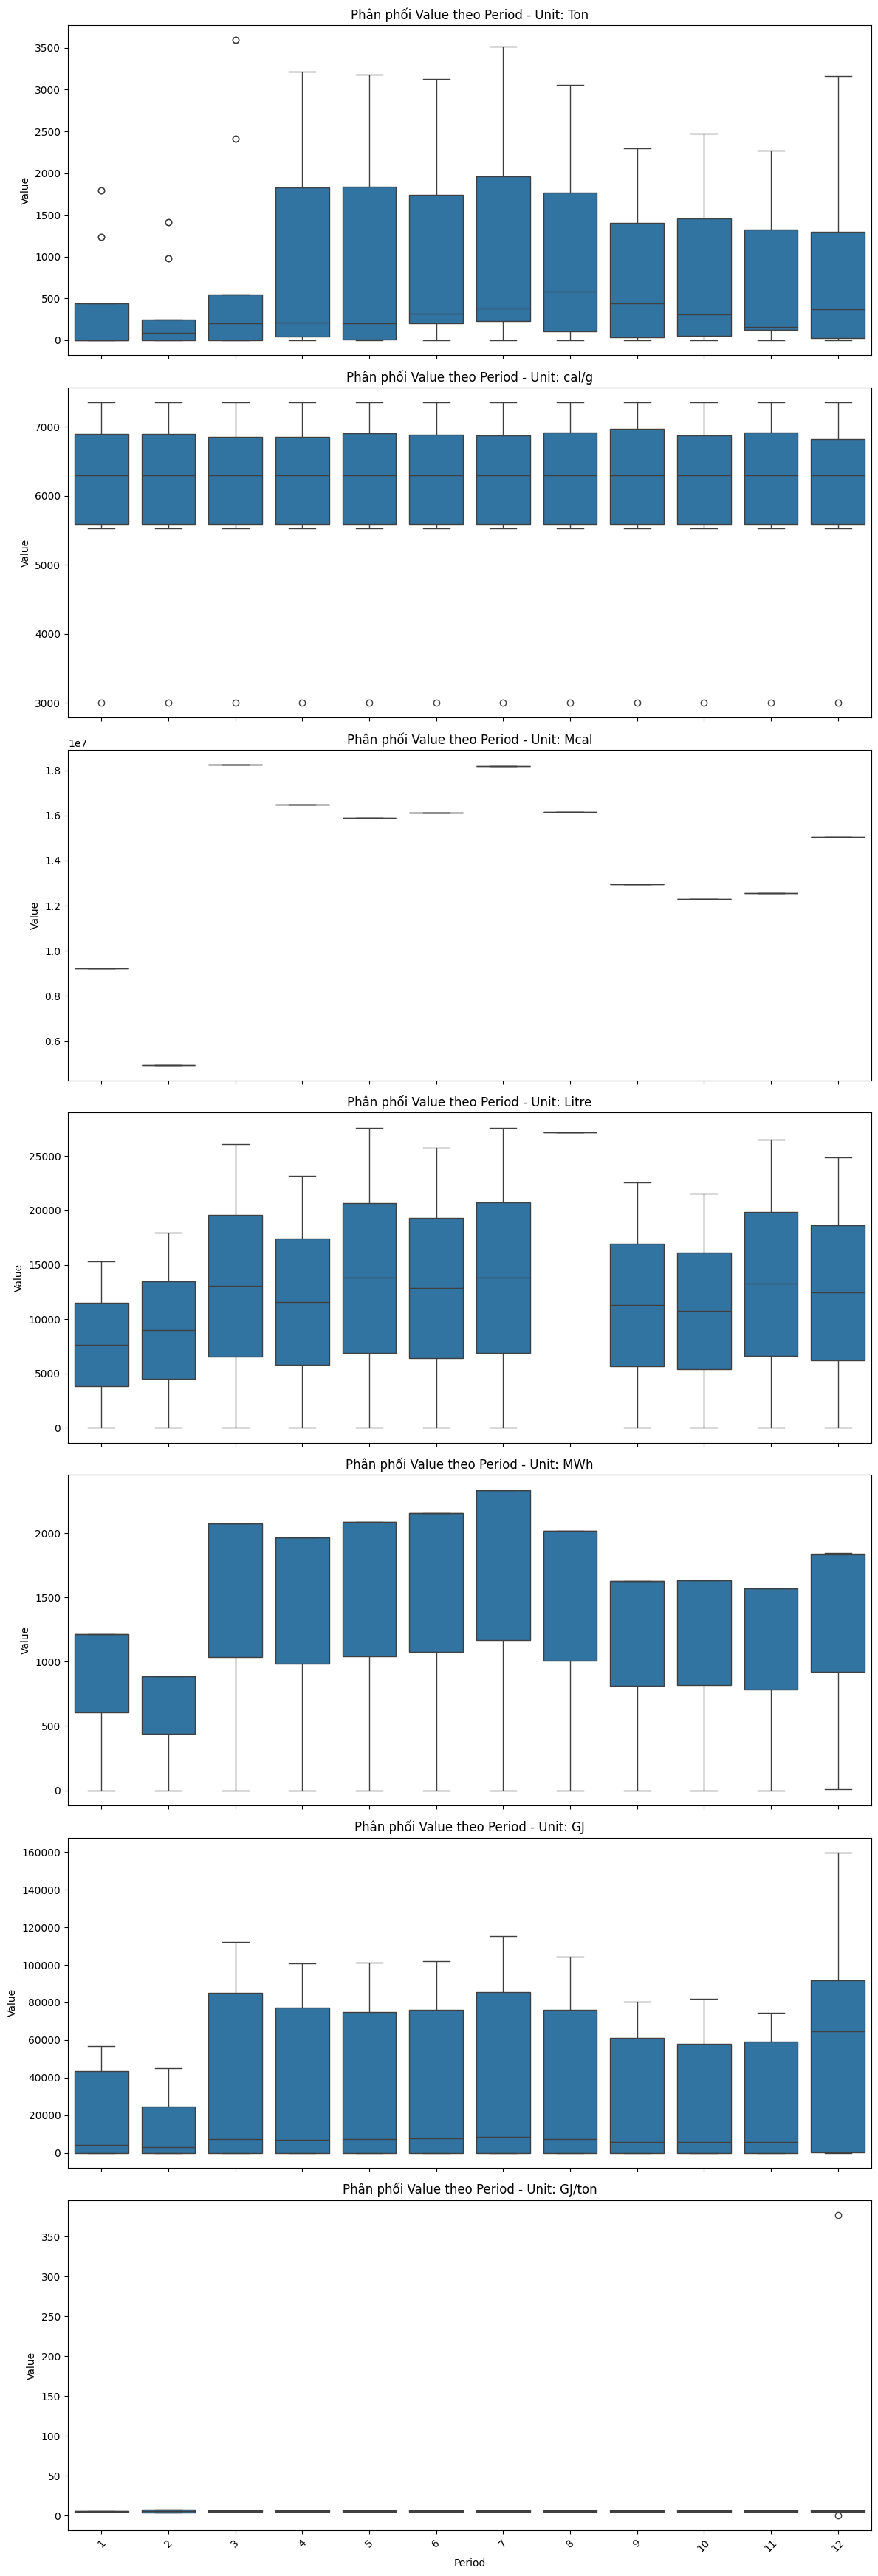

In [387]:
units = df_long['unit'].unique()
n_units = len(units)
fig, axes = plt.subplots(n_units, 1, figsize=(12, 5 * n_units), sharex=True)

for i, unit in enumerate(units):
    ax = axes[i] if n_units > 1 else axes
    sns.boxplot(data=df_long[df_long['unit'] == unit], x='month', y='value', order=df_long['month'].sort_values().unique(), ax=ax)
    ax.set_title(f'Phân phối Value theo Period - Unit: {unit}')
    ax.set_xlabel('Period')
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

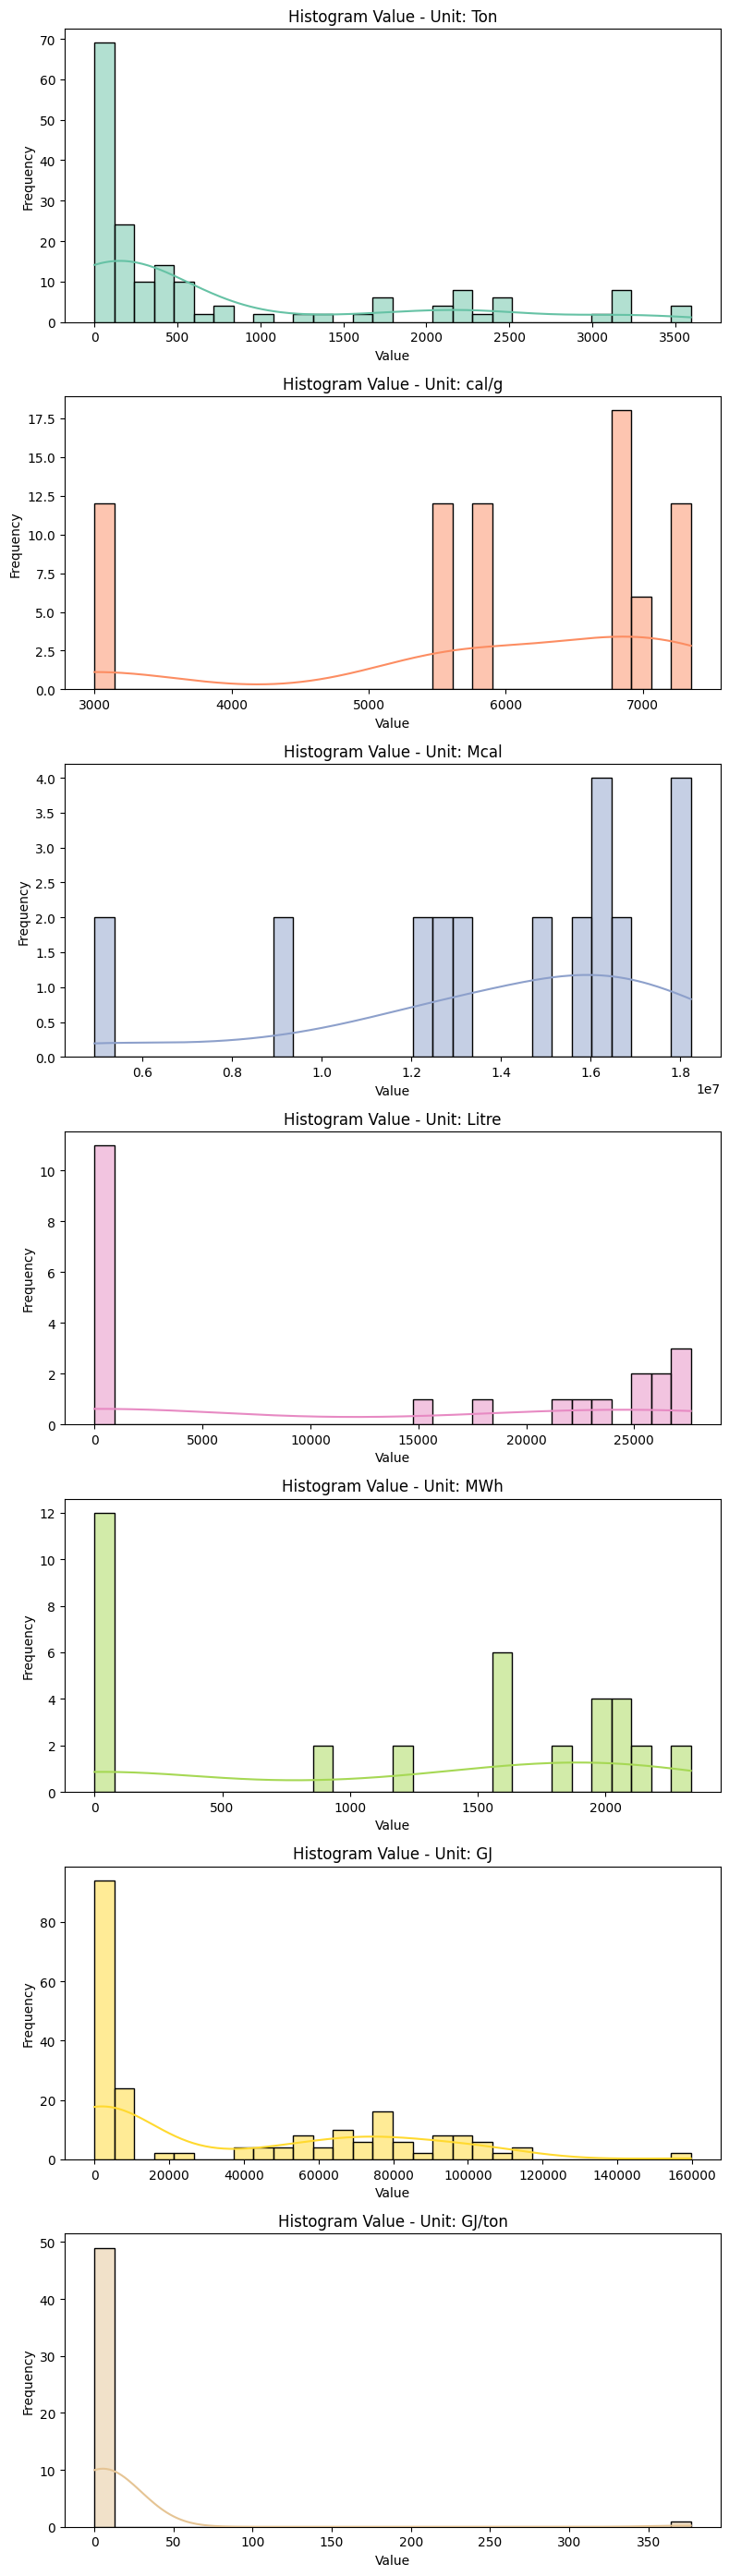

In [388]:
units = df_long['unit'].unique()
n_units = len(units)
colors = sns.color_palette("Set2", n_units) 

fig, axes = plt.subplots(n_units, 1, figsize=(8, 4 * n_units), sharex=False)

for i, unit in enumerate(units):
    ax = axes[i] if n_units > 1 else axes
    data = df_long[df_long['unit'] == unit]['value']
    sns.histplot(data, bins=30, kde=True, ax=ax, color=colors[i])
    ax.set_title(f'Histogram Value - Unit: {unit}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Phân tích Phân phối Dữ liệu ESG** 

### 1. Xu hướng Chung (Skewness & Kurtosis)
* **Lệch phải (Right-Skewed):** Hầu hết các đơn vị (`Ton`, `Litre`, `MWh`, `GJ`) tập trung mật độ cao sát mức 0. Phần lớn các cơ sở có quy mô nhỏ, trong khi một số ít "Outliers" chiếm tỷ trọng tiêu thụ/phát thải áp đảo.
* **Dữ liệu thưa thớt (Sparse Data):** Ở dải giá trị cao, các cột Histogram rời rạc, cho thấy sự biến động cực lớn giữa các đối tượng báo cáo.

### 2. Đặc điểm theo Nhóm Chỉ số
* **Nhóm Định lượng (Khối lượng/Năng lượng):** - Tập trung 90% ở dải giá trị thấp ($< 10\%$ trục X). 
    - Phản ánh sự chênh lệch quy mô (Scale) rất lớn trong hạ tầng ESG.
* **Nhóm Nhiệt trị (cal/g):** - **Phân phối đa đỉnh (Multimodal):** Xuất hiện các cụm tại ~3000, 6000, và 7000. 
    - Phân tách rõ rệt đặc tính các loại nhiên liệu (Than nội địa vs. Than nhập khẩu).
* **Nhóm Cường độ (GJ/ton):** - Phát hiện điểm dị biệt cực đoan (>350 GJ/ton). Khả năng cao là sai số nhập liệu (Input Error).

### 3. Đánh giá Chất lượng & Xử lý Dữ liệu
* **Data Gap:** Tần suất giá trị 0 quá cao cần kiểm tra lại là "không sử dụng" hay "thiếu dữ liệu" (Missing Values).
* **Khuyến nghị Pipeline:** - Áp dụng **Log Transformation** để giảm độ lệch (Skewness) trước khi đưa vào mô hình dự báo.
    - Sử dụng **Trung vị (Median)** thay cho Trung bình (Mean) để tránh nhiễu do Outliers.

## Fill Missing Values by Imputation

### Lý thuyết các phương pháp Imputation:

1. **Trung vị (Median)** - Phù hợp với dữ liệu có phân phối lệch (Skewed), ít bị ảnh hưởng bởi outliers
2. **Giá trị phổ biến nhất (Mode)** - Phù hợp với dữ liệu categorical hoặc có nhiều giá trị trùng lặp  
3. **Forward Fill** - Dùng giá trị trước đó, phù hợp cho chuỗi thời gian
4. **KNN Imputation** - Dự đoán dựa trên k hàng xóm gần nhất (kỹ thuật tiên tiến)

In [389]:
df_median = df_long.copy()
# Median theo từng sản phẩm
df_median['value'] = df_median.groupby('name_no_vn')['value'].transform(
    lambda x: x.fillna(x.median())
)

print(f"Missing values sau Median Imputation: {df_median['value'].isnull().sum()}")
print(f"Thống kê cột 'value' sau imputation:\n{df_median['value'].describe()}\n")


sample_name = df_median['name_no_vn'].iloc[0]
display(df_median[df_median['name_no_vn'] == sample_name][['name_no_vn', 'unit', 'period', 'value']].head(10))

Missing values sau Median Imputation: 108
Thống kê cột 'value' sau imputation:
count    6.600000e+02
mean     5.224216e+05
std      2.716825e+06
min      0.000000e+00
25%      0.000000e+00
50%      4.900025e+02
75%      6.920264e+03
max      1.823396e+07
Name: value, dtype: float64



c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\HP\AppData\Local

,name_no_vn,unit,period,value
0,Coal 5A (DV),Ton,jan,1233.522
65,Coal 5A (DV),Ton,feb,983.000
130,Coal 5A (DV),Ton,mar,2414.661
195,Coal 5A (DV),Ton,apr,2198.795
260,Coal 5A (DV),Ton,may,2197.301
325,Coal 5A (DV),Ton,jun,2170.990
390,Coal 5A (DV),Ton,jul,2442.916
455,Coal 5A (DV),Ton,aug,2148.882
520,Coal 5A (DV),Ton,sep,1718.913
585,Coal 5A (DV),Ton,oct,1753.955


Xem lại phân phối dữ liệu để chọn phương pháp imputation phù hợp, tránh làm sai lệch dữ liệu gốc. Nếu phân phối có nhiều outliers, ưu tiên dùng median thay vì mean. Nếu dữ liệu có nhiều giá trị trùng lặp, mode có thể là lựa chọn tốt. Với dữ liệu chuỗi thời gian, forward fill giúp duy trì tính liên tục. KNN Imputation phù hợp khi có mối quan hệ phức tạp giữa các biến.

KNN imputation cho NaN theo từng nhóm sản phẩm (name_no_vn), nếu nhóm đó có NaN thì sẽ tìm k hàng xóm gần nhất dựa trên name_no_vn và unit để điền giá trị, nếu vẫn còn NaN sau KNN thì sẽ fallback về median của nhóm đó.

In [396]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

df_knn = df_long.copy()

print(f"Missing values TRƯỚC KNN Imputation: {df_knn['value'].isnull().sum()}")

def knn_impute_by_group(group):
    if group['value'].isnull().sum() == 0:
        return group
    
    if group['value'].isnull().all():
        unit_val = group['unit'].iloc[0]
        median_val = df_long[df_long['unit'] == unit_val]['value'].median()
        if pd.isna(median_val):
            median_val = df_long['value'].median()
        group['value'] = group['value'].fillna(median_val)
        return group
    
    if len(group) < 2:
        unit_val = group['unit'].iloc[0]
        median_val = df_long[df_long['unit'] == unit_val]['value'].median()
        if pd.isna(median_val):
            median_val = df_long['value'].median()
        group['value'] = group['value'].fillna(median_val)
        return group
    
    try:
        imputer = KNNImputer(n_neighbors=min(5, len(group)-1), weights='uniform')
        
        group_temp = group.copy()
        le_unit = LabelEncoder()
        group_temp['unit_encoded'] = le_unit.fit_transform(group_temp['unit'])
        
        cols_for_impute = ['value', 'month', 'unit_encoded']
        group_temp[cols_for_impute] = imputer.fit_transform(group_temp[cols_for_impute])
        
        group['value'] = group_temp['value'].values
        return group
    except Exception as e:
        print(f"  KNN failed for group, using fallback median")
        unit_val = group['unit'].iloc[0]
        median_val = df_long[df_long['unit'] == unit_val]['value'].median()
        if pd.isna(median_val):
            median_val = df_long['value'].median()
        group['value'] = group['value'].fillna(median_val)
        return group

df_knn = df_knn.groupby('name_no_vn', group_keys=False).apply(knn_impute_by_group)

missing_count = df_knn['value'].isnull().sum()
print(f"Missing values SAU KNN Imputation: {missing_count}")

# Fallback toàn cục nếu vẫn còn NaN
if missing_count > 0:
    print(f"  Applying global median fallback for remaining {missing_count} NaN values...")
    global_median = df_knn['value'].median()
    df_knn['value'] = df_knn['value'].fillna(global_median)
    print(f"  Missing values sau fallback: {df_knn['value'].isnull().sum()}")

print(f"Phương pháp KNN sử dụng k=5 hàng xóm gần nhất (tính theo sản phẩm)\n")

sample_product = df_knn['name_no_vn'].iloc[0]
print(f"Kiểm tra sản phẩm '{sample_product}' sau KNN imputation:")
display(df_knn[df_knn['name_no_vn'] == sample_product][
    ['name_no_vn', 'unit', 'month', 'period', 'value']
].head(12))

=== 4. KNN IMPUTATION (Advanced - By Name_no_vn) + Fallback ===

Missing values TRƯỚC KNN Imputation: 166
Missing values SAU KNN Imputation: 0
Phương pháp KNN sử dụng k=5 hàng xóm gần nhất (tính theo sản phẩm)

Kiểm tra sản phẩm 'Coal 5A (DV)' sau KNN imputation:


C:\Users\HP\AppData\Local\Temp\ipykernel_18172\302470366.py:51: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_knn = df_knn.groupby('name_no_vn', group_keys=False).apply(knn_impute_by_group)


,name_no_vn,unit,month,period,value
0,Coal 5A (DV),Ton,1,jan,1233.522
65,Coal 5A (DV),Ton,2,feb,983.000
130,Coal 5A (DV),Ton,3,mar,2414.661
195,Coal 5A (DV),Ton,4,apr,2198.795
260,Coal 5A (DV),Ton,5,may,2197.301
325,Coal 5A (DV),Ton,6,jun,2170.990
390,Coal 5A (DV),Ton,7,jul,2442.916
455,Coal 5A (DV),Ton,8,aug,2148.882
520,Coal 5A (DV),Ton,9,sep,1718.913
585,Coal 5A (DV),Ton,10,oct,1753.955


In [410]:
comparison_data = {
    'Phương pháp': ['Trước Imputation', 'Median (By Name)', 'KNN (By Name)'],
    'Missing Values': [
        df_long['value'].isnull().sum(),
        df_median['value'].isnull().sum(),
        df_knn['value'].isnull().sum()
    ],
    'Mean': [
        df_long['value'].mean(),
        df_median['value'].mean(),
        df_knn['value'].mean()
    ],
    'Median': [
        df_long['value'].median(),
        df_median['value'].median(),
        df_knn['value'].median()
    ],
    'Std Dev': [
        df_long['value'].std(),
        df_median['value'].std(),
        df_knn['value'].std()
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


     Phương pháp  Missing Values          Mean    Median      Std Dev
Trước Imputation             166 572747.707867 1630.3408 2.839823e+06
Median (By Name)               0 690723.801501  376.9460 3.137286e+06
   KNN (By Name)               0 690723.801501  376.9460 3.137286e+06


Nhận xét kết quả Imputation (Xử lý dữ liệu thiếu)

Phân tích biến động thống kê:
* **Độ lệch Mean (Trung bình):** Cả hai phương pháp **Median** và **KNN** đều làm tăng giá trị Mean (từ ~572,747 lên ~690,723). 
    - *Giải thích:* Điều này cho thấy các giá trị bị thiếu không xuất hiện ngẫu nhiên mà chủ yếu nằm ở các nhóm có mức tiêu thụ/phát thải cao. Việc lấp đầy khoảng trống đã kéo mức trung bình tổng thể lên.
* **Độ lệch Std Dev (Độ lệch chuẩn):** Std Dev tăng đáng kể (từ 2.83e+06 lên 3.13e+06). 
    - *Nhận xét:* Dữ liệu sau khi lấp đầy có độ biến động cao hơn, chứng tỏ các giá trị được điền vào làm gia tăng sự phân tán của tập dữ liệu.


### Remove Outliers
- Sử dụng IQR hoặc Z-score để xác định và loại bỏ các giá trị ngoại lai (Outliers) có thể ảnh hưởng đến phân tích và mô hình hóa dữ liệu.
- Cần phân tích rõ có phải là outliers thực sự hay chỉ là các cơ sở có quy mô lớn, từ đó đưa ra quyết định giữ lại hay loại bỏ.
--> Có nhiều mectric/KPI khác nhau nên không dùng remove

### Correlation Analysis
- Tính toán ma trận tương quan giữa các biến định lượng (value) để xác định mối quan hệ giữa các loại sản phẩm và các chỉ số phát thải.
- Sử dụng heatmap để trực quan hóa ma trận tương quan, giúp nhận diện các mối quan hệ mạnh giữa các biến, từ đó có thể rút ra những insight quan trọng về nguồn phát thải và tiêu thụ năng lượng.

Chuyển sang long để giảm độ lệch và dễ dàng xử lý hơn, sau đó có thể áp dụng các kỹ thuật như log transformation để giảm ảnh hưởng của outliers.

In [421]:
num_cols = ['value']
print(num_cols)

['value']


In [433]:
# log transformation
import numpy as np
df_long_log = df_median.copy()
for col in num_cols:
    df_long_log[col] = df_long_log[col].apply(lambda x: np.log(x) if pd.notnull(x) and x > 0 else x)


In [435]:
df_long_log.head()

,name,name_no_vn,unit,period,value,month
0,Coal/ Than 5A (DV),Coal 5A (DV),Ton,jan,7.117629,1
1,Coal/ Than 4A.1 (DV),Coal 4A.1 (DV),Ton,jan,6.093570,1
2,Coal/ Than import coal (DV) (than nhập khẩu),Coal import coal (DV),Ton,jan,0.000000,1
3,Than cám qua sàng / Than 5A under screen DV,Coal 5A under screen DV,Ton,jan,4.736198,1
4,Coal/ Than 5A (YB),Coal 5A (YB),Ton,jan,0.000000,1


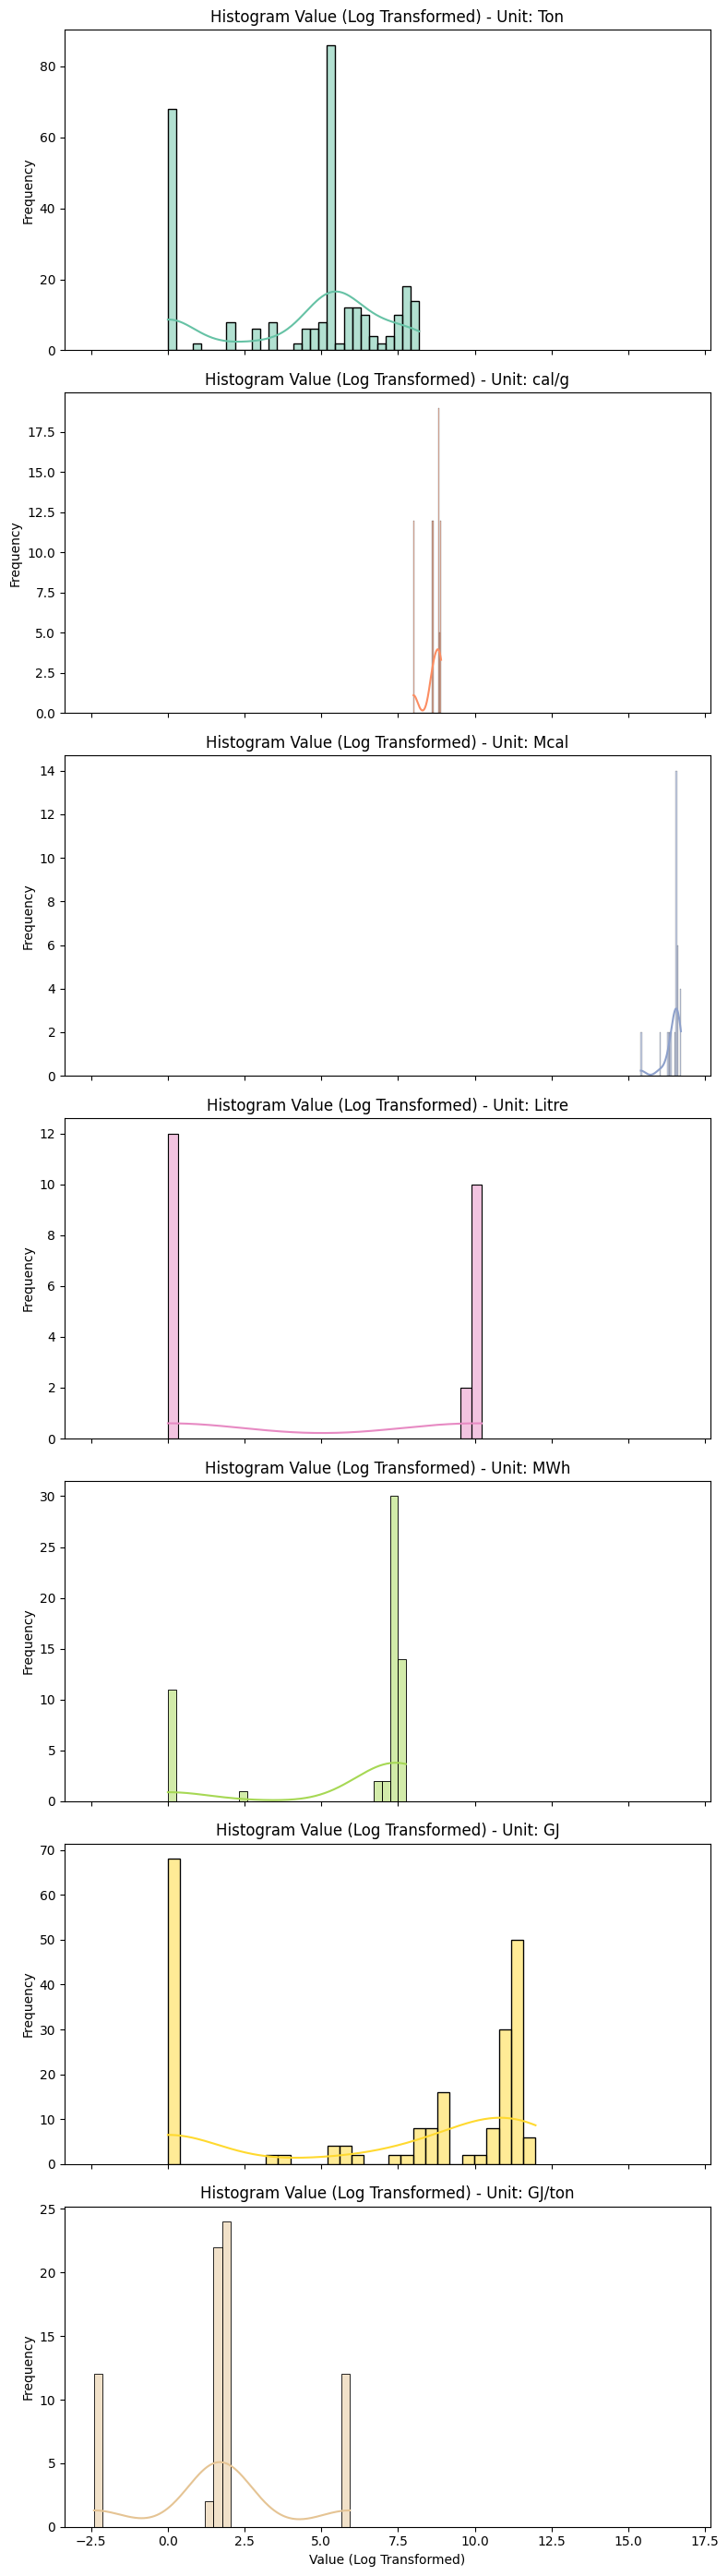

In [436]:
# biểu đồ histogram sau log transformation
units = df_long_log['unit'].unique()
n_units = len(units)
fig, axes = plt.subplots(n_units, 1, figsize=(8, 4 * n_units), sharex=True)
for i, unit in enumerate(units):
    ax = axes[i] if n_units > 1 else axes
    data = df_long_log[df_long_log['unit'] == unit]['value']
    sns.histplot(data, bins=30, kde=True, ax=ax, color=colors[i])
    ax.set_title(f'Histogram Value (Log Transformed) - Unit: {unit}')
    ax.set_xlabel('Value (Log Transformed)')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

Sự thay đổi của các chỉ số Intensity (`GJ/ton`)
* Biểu đồ `GJ/ton` hiện tại cho thấy một phân phối **gần chuẩn (Normal-like)** nhất trong tất cả các biểu đồ, tập trung quanh giá trị Log ~2.
* Điều này cực kỳ quan trọng vì trong ESG, chỉ số cường độ (Intensity) thường là mục tiêu chính để tối ưu hóa. Việc nó có phân phối chuẩn giúp các thuật toán thống kê hoạt động chính xác hơn.

Nhận diện các cụm dữ liệu (Clustering Potential)
* Các đường KDE (đường cong xanh) không còn dốc đứng mà đã trải dài ra, lộ rõ các khoảng trống (gaps) giữa các đỉnh. 
* **Ý nghĩa:** Có thể dễ dàng phân loại các đơn vị báo cáo thành các nhóm: "Nhóm tiêu thụ thấp", "Nhóm trung bình" và "Nhóm trọng điểm" dựa trên các điểm lõm của phân phối này.

 Đánh giá chất lượng xử lý
* **Ưu điểm:** Log Transform đã "kéo" các Outliers vào gần trung tâm hơn, giúp Std Dev giảm đi đáng kể trên thang đo mới, làm cho mô hình 

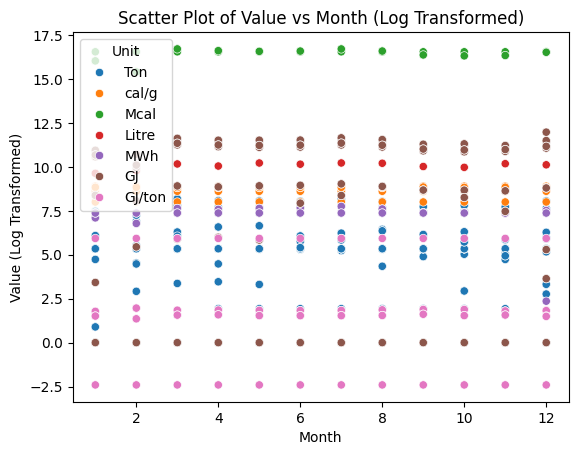

In [437]:
# tương quan giữa value và month
sns.scatterplot(data=df_long_log, x='month', y='value', hue='unit')
plt.title('Scatter Plot of Value vs Month (Log Transformed)')
plt.xlabel('Month')
plt.ylabel('Value (Log Transformed)')
plt.legend(title='Unit')
plt.show()

- Không có tương quan 
- Thấy rõ các cụm sản phẩm có đặc tính tương đồng (ví dụ: các loại than nội địa tập trung ở một cụm, trong khi than nhập khẩu tập trung ở cụm khác). Điều này phản ánh sự khác biệt về nguồn gốc và chất lượng nhiên liệu, từ đó ảnh hưởng đến mức độ phát thải và tiêu thụ năng lượng của từng nhóm sản phẩm.

### Transform Wide to Long Format for Heatmap Visualization

In [438]:
df_pivot = df_long_log.pivot_table(
    index='month',
    columns='name_no_vn',
    values='value'
)
df_pivot.reset_index(inplace=True)
df_pivot.head()

name_no_vn,month,Co-generation (Heat),Co-generation (Power),Coal 5A under screen (DV+YB),Coal 4A.1 (DV),Coal 4A.1 (DV+YB),Coal 4A.1 (YB),Coal 5A (DV),Coal 5A (DV+YB),Coal 5A (YB),...,Total Renewable Energy,Total Renewable Energy (DV),Total Renewable Energy (YB),Total Solid Biomass,Total Thermal Consumption-Coal Gas,Total Thermal Consumption-Coal Gas (DV),Total Thermal Consumption-Coal Gas (YB),"Total Thermal Consumption-Coal, Biomass","Total Thermal Consumption-Coal, Biomass (DV)","Total Thermal Consumption-Coal, Biomass (YB)"
0,1,5.343315,7.377646,4.736198,6.093570,6.093570,0.000000,7.117629,7.117629,0.0,...,3.424812,3.424812,0.0,0.894454,10.578001,10.578001,0.0,10.870128,10.870128,0.0
1,2,5.343315,7.377646,4.477337,5.526448,5.526448,0.000000,6.890609,6.890609,0.0,...,5.450504,5.450504,0.0,2.920146,9.966110,9.966110,0.0,10.641955,10.641955,0.0
2,3,5.343315,7.377646,5.329520,6.297236,6.297236,0.000000,7.789314,7.789314,0.0,...,5.899961,5.899961,0.0,3.369604,11.257758,11.257758,0.0,11.559510,11.559510,0.0
3,4,5.343315,7.377646,5.343315,4.481136,4.481136,1.932359,7.695665,7.695665,0.0,...,5.994092,5.994092,0.0,3.463734,11.155980,11.155980,0.0,11.448605,11.448605,0.0
4,5,5.343315,7.377646,5.321541,6.651817,6.651817,1.932359,7.694985,7.694985,0.0,...,5.842797,5.842797,0.0,3.312439,11.119525,11.119525,0.0,11.445938,11.445938,0.0


In [445]:


df_numeric = df_pivot.select_dtypes(include=['number'])
corr = df_numeric.corr()

mask = np.triu(np.ones_like(corr), k=1).astype(bool)
corr_upper = corr.where(mask)

high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        corr_val = corr.iloc[i, j]
        if abs(corr_val) >= 0.7:  
            high_corr_pairs.append({
                'Variable 1': corr.columns[i],
                'Variable 2': corr.columns[j],
                'Correlation': corr_val
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)

display(high_corr_df.head(20)) 


,Variable 1,Variable 2,Correlation
3,Coal 5A under screen (DV+YB),Coal 5A under screen DV,1.000000
19,Coal import coal (DV),Coal import coal (DV+YB),1.000000
7,Coal 5A (DV),Coal 5A (DV+YB),1.000000
6,Coal 4A.1 (DV),Coal 4A.1 (DV+YB),0.999810
21,"Specific Energy Consumption-Coal, Biomass","Specific Energy Consumption-Coal, Biomass (DV)",0.993104
20,Specific Energy Consumption-Coal Gas,Specific Energy Consumption-Coal Gas (DV),0.993102
9,Coal 5A (DV),Coal Gas (DV),0.974907
12,Coal 5A (DV+YB),Coal Gas (DV),0.974907
11,Coal 5A (DV+YB),Coal 5A under screen DV,0.964930
8,Coal 5A (DV),Coal 5A under screen DV,0.964930


- Khi tăng giá trị của một chỉ số, chắc chắn total sẽ tăng.
- Có tương quan ở Solid Biomass (DV) -> Total Renewable Energy (DV) -> Total Renewable Energy, tức là Renewable Energy chủ yếu đến từ Solid Biomass, không có nguồn nào khác. 

Bảng tương quan này lộ ra cấu trúc "Cha - Con" trong mô hình dữ liệu ESG:
* `Solid Biomass (DV)` -> `Total Renewable Energy (DV)` -> `Total Renewable Energy`.
* Mối quan hệ bắc cầu này (A=B, B=C => A=C) cho thấy hệ thống đang chạy các phép tính cộng dồn (Roll-up) rất tuyến tính.


Trong tương lai khi phân tích mô hình cần: 
* **Loại bỏ đa cộng tuyến (Multicollinearity):** Nếu đưa các biến này vào mô hình hồi quy (Regression) để dự báo phát thải, **BẮT BUỘC** phải loại bỏ các biến có tương quan bằng 1. Việc giữ cả hai sẽ làm ma trận bị suy biến (Singular matrix) và mô hình không thể hội tụ.
* **Tinh gọn tầng Gold:** * Chỉ nên giữ lại các biến tổng (`Total`) hoặc biến thành phần chi tiết nhất để làm Feature, tránh đưa cả hai vào cùng một bảng Analytics để tiết kiệm tài nguyên lưu trữ và xử lý.
    * Kiểm tra lại các trường hợp `DV+YB` nếu giá trị của một bên luôn bằng 0, có thể cân nhắc gộp logic ngay từ tầng chuẩn hóa (Silver).


Loại bỏ Total để xem các mối quan hệ giữa các biến thành phần, nếu vẫn có tương quan cao thì mới giữ lại Total để phân tích, nếu không có tương quan thì có thể loại bỏ Total để giảm đa cộng tuyến khi đưa vào mô hình dự báo.

In [ ]:
df_pivot = df_pivot.loc[:, ~df_pivot.columns.str.contains('Total', case=False, na=False)]
df_pivot.head()

name_no_vn,month,Co-generation (Heat),Co-generation (Power),Coal 5A under screen (DV+YB),Coal 4A.1 (DV),Coal 4A.1 (DV+YB),Coal 4A.1 (YB),Coal 5A (DV),Coal 5A (DV+YB),Coal 5A (YB),...,Solid Biomass (DV),Solid Biomass (YB),Solid Biomass heating Value,Specific Energy Consumption-Coal Gas,Specific Energy Consumption-Coal Gas (DV),Specific Energy Consumption-Coal Gas (YB),"Specific Energy Consumption-Coal, Biomass","Specific Energy Consumption-Coal, Biomass (DV)","Specific Energy Consumption-Coal, Biomass (YB)",Steam
0,1,5.343315,7.377646,4.736198,6.093570,6.093570,0.000000,7.117629,7.117629,0.0,...,0.894454,0.0,8.006368,1.513050,1.513050,-2.407946,1.779462,1.779462,5.932102,5.343315
1,2,5.343315,7.377646,4.477337,5.526448,5.526448,0.000000,6.890609,6.890609,0.0,...,2.920146,0.0,8.006368,1.355656,1.355656,-2.407946,1.965420,1.965420,5.932102,5.343315
2,3,5.343315,7.377646,5.329520,6.297236,6.297236,0.000000,7.789314,7.789314,0.0,...,3.369604,0.0,8.006368,1.566704,1.566704,-2.407946,1.845265,1.845265,5.932102,5.343315
3,4,5.343315,7.377646,5.343315,4.481136,4.481136,1.932359,7.695665,7.695665,0.0,...,3.463734,0.0,8.006368,1.584972,1.584972,-2.407946,1.853989,1.853989,5.932102,5.343315
4,5,5.343315,7.377646,5.321541,6.651817,6.651817,1.932359,7.694985,7.694985,0.0,...,3.312439,0.0,8.006368,1.539127,1.539127,-2.407946,1.837217,1.837217,5.932102,5.343315


===  TOP CORRELATIONS 0.7+ ===


,Variable 1,Variable 2,Correlation
3,Coal 5A under screen (DV+YB),Coal 5A under screen DV,1.000000
19,Coal import coal (DV),Coal import coal (DV+YB),1.000000
7,Coal 5A (DV),Coal 5A (DV+YB),1.000000
6,Coal 4A.1 (DV),Coal 4A.1 (DV+YB),0.999810
21,"Specific Energy Consumption-Coal, Biomass","Specific Energy Consumption-Coal, Biomass (DV)",0.993104
20,Specific Energy Consumption-Coal Gas,Specific Energy Consumption-Coal Gas (DV),0.993102
9,Coal 5A (DV),Coal Gas (DV),0.974907
12,Coal 5A (DV+YB),Coal Gas (DV),0.974907
11,Coal 5A (DV+YB),Coal 5A under screen DV,0.964930
8,Coal 5A (DV),Coal 5A under screen DV,0.964930


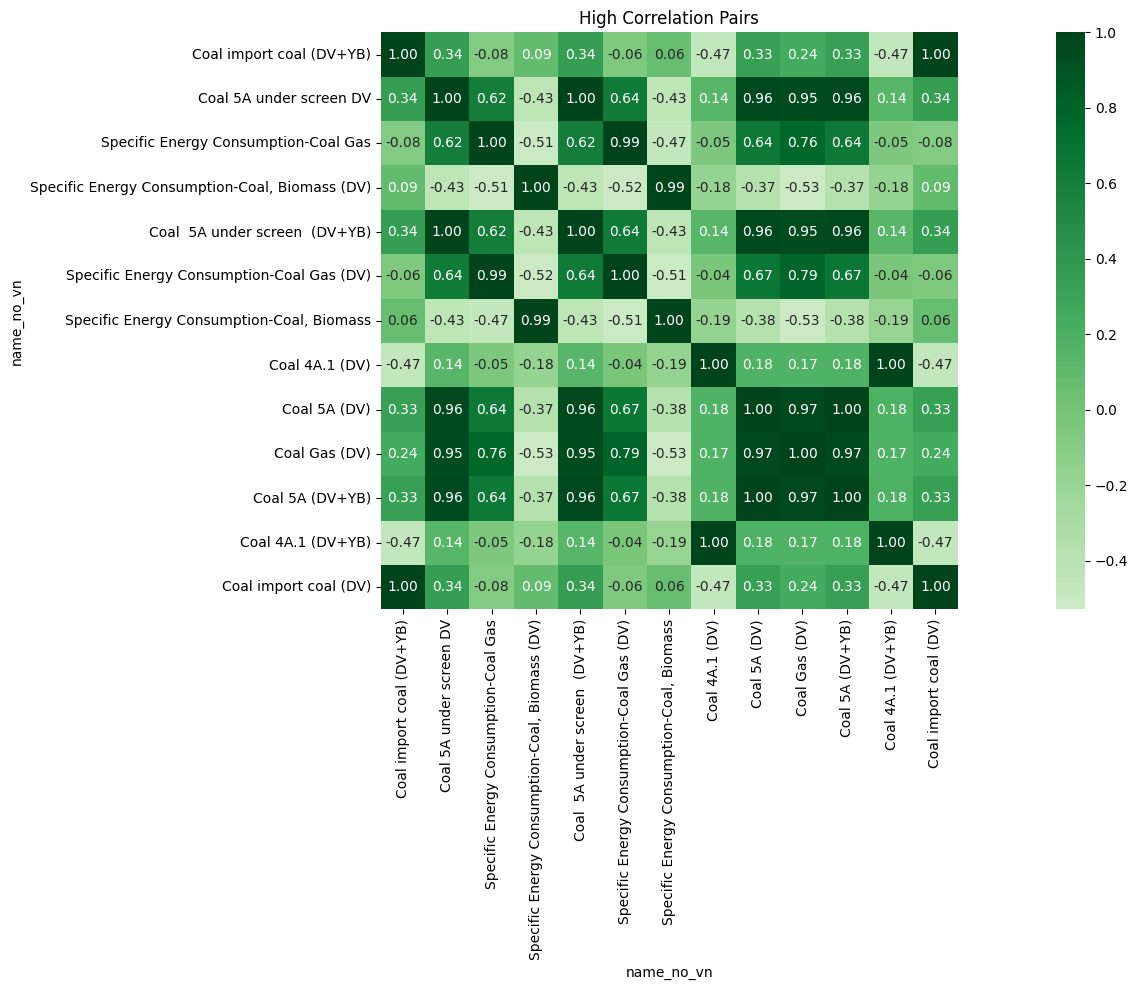

In [ ]:
df_numeric = df_pivot.select_dtypes(include=['number'])
corr = df_numeric.corr()

mask = np.triu(np.ones_like(corr), k=1).astype(bool)
corr_upper = corr.where(mask)


high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        corr_val = corr.iloc[i, j]
        if abs(corr_val) >= 0.7: 
            high_corr_pairs.append({
                'Variable 1': corr.columns[i],
                'Variable 2': corr.columns[j],
                'Correlation': corr_val
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)

print(f"===  TOP CORRELATIONS {abs(0.7)}+ ===")
display(high_corr_df.head(20))  

top_vars = list(set(high_corr_df['Variable 1'].head(10).tolist() + high_corr_df['Variable 2'].head(10).tolist()))
corr_filtered = corr.loc[top_vars, top_vars]

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(corr_filtered, annot=True, cmap='Greens', center=0, fmt='.2f', ax=ax, square=True)
ax.set_title('High Correlation Pairs')
plt.tight_layout()
plt.show()



1. Dư thừa dữ liệu (Correlation = 1.0)
* **Coal 5A, Coal import (DV vs DV+YB):** Tương quan tuyệt đối cho thấy số liệu tại **YB bằng 0** hoặc không biến động. Biến tổng đang sao chép hoàn toàn biến đơn.
* **Hành động:** Loại bỏ các cột `DV+YB` ở tầng Gold để tối ưu lưu trữ và tránh lỗi đa cộng tuyến (Multicollinearity).

2. Logic vận hành sản xuất
* **Than & Khí (0.975):** Mối quan hệ giữa `Coal 5A` và `Coal Gas` cực kỳ chặt chẽ. Đây là dấu hiệu tốt cho thấy pipeline dữ liệu phản ánh đúng thực tế lò đốt (đốt than sinh khí).
* **Năng lượng & Khối lượng (0.993):** Chỉ số tiêu thụ năng lượng đặc thù (SEC) phụ thuộc hoàn toàn vào dữ liệu phía DV.

3. Yếu tố mùa vụ và Vận chuyển
* **Tính mùa vụ (0.831):** Tiêu thụ than tại **YB** phụ thuộc lớn vào biến thời gian (`month`). Cần lưu ý biến này khi làm mô hình dự báo.
* **Diesel & Sản xuất (~0.84):** Hoạt động vận tải (Diesel) biến động đồng nhất với sản lượng than tiêu thụ nhưng vẫn có độ lệch nhất định, cần tách biệt trong báo cáo Scope 1.
